## Ground Truth Generation

In [ ]:
#%pip install networkx graphviz numpy pgmpy torch

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.1 MB 366.1 kB/s eta 0:05:32
   ---------------------------------------- 0.5/122.1 MB 366.1 kB/s eta 0:05:32
   ---------------------------------------- 0.5/122.1 MB 366.1 kB/s eta 0:05:32
   ---------------------------------------- 0.8/122.1 MB 389.1 kB/s eta 0:05:12
   ---------------------------------------- 0.8/1

In [1]:
import random
import graphviz
import networkx as nx
import numpy as np
import os, time
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.parameter_estimator import DiscreteMLE

import torch
import torch.nn as nn

c:\Users\Kaylin\OneDrive\2026\Research\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DAG Generation

In [123]:
#min in-degree?
def generate_dag(n, max_in_degree, max_density, seed):

    # Random topological order
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)

    # Create DAG
    G = nx.DiGraph()
    G.add_nodes_from(order)
    max_edges = round(max_density*n*(n-1)/2)

    # Feasibility Check
    ceiling = sum(min(i, max_in_degree) for i in range(n))
    if max_edges > ceiling:
        print(f"warning: density {max_density} needs {max_edges} edges, but max in-degree allows only {ceiling}")
        max_edges = ceiling
        max_density = max_edges / (n*(n-1)/2)

    # Backbone - Ensure weak connectivity
    for i in range(1, n):
        child = order[i]
        parent = rng.choice(order[:i])
        G.add_edge(parent, child)

    # Extra edges
    possible_edges = [(order[i], order[j]) for j in range(n) for i in range(j)]
    rng.shuffle(possible_edges)

    for u,v in possible_edges:
        if(G.has_edge(u,v)):
            continue
        if(G.number_of_edges() >= max_edges):
            break

        G.add_edge(u,v)
        if(G.number_of_edges() / (n*(n-1)/2) >= max_density):
            G.remove_edge(u,v)
            break

    print(f"max in-degree = {max_in_degree} \nmax density = {round(max_density,2)}")

    return G
 

#### Test

max in-degree = 3 
max density = 0.64


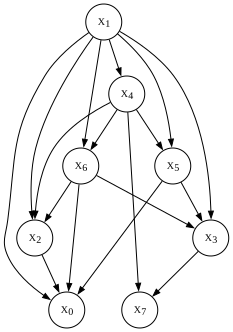

In [124]:
N_NODES = 8
CARDINALITY = 2
ALPHA = 1.0

MAX_IN_DEGREE = 3
MAX_DENSITY = 0.8

dag = generate_dag(
    n=N_NODES,
    max_in_degree=MAX_IN_DEGREE,
    max_density=MAX_DENSITY,
    seed=123
)

dot = graphviz.Digraph(
    graph_attr={"rankdir": "TB"},
    node_attr={"width": "0.5", "height": "0.5", "fontsize": "10"},
    edge_attr={"arrowsize": "0.7"},
)

for u, v in dag.edges:
    dot.edge(u, v)

for i in range(N_NODES):
    node_id = f"X_{i}"
    dot.node(node_id, label=f"<X<SUB>{i}</SUB>>")

dot

### Ground Truth CPTs
Populate ground-truth CPTs from Dirichlet

In [125]:
def gen_CPTs(G, card, alpha, seed):

    rng = np.random.default_rng(seed)
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    cpds = []
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        n_configs = card ** len(parents)
        vals = rng.dirichlet([alpha] * card, size=n_configs).T   # (card, n_configs)
        cpd = TabularCPD(
            variable=node, variable_card=card, values=vals,
            evidence=parents or None,
            evidence_card=[card] * len(parents) or None,
            state_names={v: list(range(card)) for v in [node] + parents},
        )
        cpds.append(cpd)
 
    model.add_cpds(*cpds)
    model.check_model()
    return model


#### Test

In [126]:
ground_truth = gen_CPTs(G=dag, card=CARDINALITY, alpha=ALPHA, seed=456)

for cpd in ground_truth.get_cpds():
    print(f"{cpd} \n")

+--------+----------+
| X_1(0) | 0.538859 |
+--------+----------+
| X_1(1) | 0.461141 |
+--------+----------+ 

+--------+---------------------+----------------------+
| X_1    | X_1(0)              | X_1(1)               |
+--------+---------------------+----------------------+
| X_4(0) | 0.32406706937795593 | 0.981314983195667    |
+--------+---------------------+----------------------+
| X_4(1) | 0.6759329306220442  | 0.018685016804333033 |
+--------+---------------------+----------------------+ 

+--------+---------------------+-----+---------------------+
| X_1    | X_1(0)              | ... | X_1(1)              |
+--------+---------------------+-----+---------------------+
| X_4    | X_4(0)              | ... | X_4(1)              |
+--------+---------------------+-----+---------------------+
| X_5(0) | 0.06863164792155352 | ... | 0.5398787090259637  |
+--------+---------------------+-----+---------------------+
| X_5(1) | 0.9313683520784465  | ... | 0.46012129097403637 |
+-----

### Evaluation Functions

In [ ]:
def node_kl_divergence(true_cpd, learned_cpd):
    eps=1e-12
    if true_cpd.variables[1:]:
        learned_cpd.reorder_parents(true_cpd.variables[1:])

    P = np.clip(true_cpd.get_values(),   eps, 1)   # (card, n_configs)
    Q = np.clip(learned_cpd.get_values(), eps, 1)
    return (P * np.log(P / Q)).sum(axis=0).mean() 

def logprob(model, data):
    return np.array([
        np.log(model.get_state_probability(dict(row)))
        for _, row in data.iterrows()
    ])

def neural_logprob(nn_models, G, data, card):
    total = np.zeros(len(data))
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        X = one_hot(data, parents, card)
        y = data[node].to_numpy().astype(int)
        with torch.no_grad():
            probs = torch.softmax(nn_models[node](X), dim=1).numpy()
        total += np.log(np.clip(probs[np.arange(len(data)), y], 1e-12, 1))
    return total

def kl_divergence(true_cpd, learned_cpd, n_test=20000, seed=999):
    # D(P* || P^) = E_{x~P*}[ log P*(x) - log P^(x) ]
    # estimated on held-out test set
    
    test = true_cpd.simulate(n_samples=n_test, seed=seed, show_progress=False)
    logp_true = logprob(true_cpd, test)
    logp_learned = logprob(learned_cpd, test)
   
    return (logp_true - logp_learned).mean()



def fit_mle(G, data, card):
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    estimator = DiscreteMLE()
    # force full state space so unobserved states aren't dropped
    estimator.state_names = {v: list(range(card)) for v in G.nodes()}
    model.fit(data, estimator=estimator)
    return model


#### Test


In [ ]:
N, CARD, ALPHA = 2000, 2, 1.0

G = generate_dag(n=8, max_in_degree=3, max_density=0.3, seed=123)
n = G.number_of_nodes()
print(f"\nDensity: {G.number_of_edges() / (n*(n-1)/2):.3f}")
print("In-degrees:", dict(sorted(G.in_degree(), key=lambda kv: kv[0])))

ground_truth = gen_CPTs(G=G, card=CARDINALITY, alpha=ALPHA, seed=456)

# sample
data = ground_truth.simulate(n_samples=N, seed=3, show_progress=False)
print(f"\nSampled {len(data)} rows")

# parameter estimation
mle_model = fit_mle(G, data, CARD)

print(f"\n{'node':>5} {'in-deg':>7} {'MLE KL':>10}")
for node in G.nodes():
    k = len(sorted(G.predecessors(node)))
    kl_mle = kl_divergence(ground_truth.get_cpds(node), mle_model.get_cpds(node))
    print(f"{node:>5} {k:>7} {kl_mle:>10.4f}")

avg_kl = np.mean([kl_divergence(ground_truth.get_cpds(nd), mle_model.get_cpds(nd)) for nd in G.nodes()])
print(f"\nMLE Mean KL = {avg_kl:.4f}")

max in-degree = 3 
max density = 0.3

Density: 0.286
In-degrees: {'X_0': 2, 'X_1': 0, 'X_2': 1, 'X_3': 1, 'X_4': 1, 'X_5': 1, 'X_6': 1, 'X_7': 1}

Sampled 2000 rows

 node  in-deg     MLE KL
  X_1       0     0.0000
  X_4       1     0.0012
  X_5       1     0.0002
  X_6       1     0.0001
  X_3       1     0.0002
  X_7       1     0.0001
  X_2       1     0.0005
  X_0       2     0.0017

MLE Mean KL=0.0005


## Neural Network CPDs

In [ ]:
# Linear Softmax Baseline
class NodeNN(nn.Module):
    # one-hot parent config -> softmax distribution over child states
    def __init__(self, n_parents, card, hidden_dims=()):
        super().__init__()
        in_dim = n_parents * card
        dims = [in_dim, *hidden_dims]
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers += [nn.Linear(dims[-1], card)]   # logits - softmax via the loss
        self.net = nn.Sequential(*layers)
 
    def forward(self, x):
        return self.net(x) # raw logits
 
 
def one_hot(data, parents, card):
    if not parents:
        return torch.zeros((len(data), 1), dtype=torch.float32)
    idx = torch.tensor(data[parents].to_numpy().astype(np.int64), dtype=torch.long)
    one_hot = torch.nn.functional.one_hot(idx, num_classes=card)   # (rows, parents, card)
    return one_hot.reshape(len(idx), -1).float()
 
 
def train_node_nn(data, node, parents, card, hidden_dims=(32,),
                  epochs=200, lr=1e-3, weight_decay=1e-4, seed=0):
    # train one neural CPD for a node given its parents
    torch.manual_seed(seed)
    X = one_hot(data[parents].to_numpy(), card)
    y = torch.tensor(data[node].to_numpy().astype(np.int64), dtype=torch.long)
 
    model = NodeNN(len(parents), card, hidden_dims)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()        # softmax + NLL in one
 
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
    return model

## Experiments

In [ ]:
# experiment configs

NODE_COUNTS  = [10, 20, 50]
IN_DEGREES   = [2, 5, 10]          # max_in_degree
DENSITIES    = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
SIM          = 5                   # random DAGs per config

CARD         = 2                   
ALPHA        = 1.0                 # Dirichlet concentration for ground-truth CPTs

SAMPLE_SIZES     = [200, 600, 1000, 1400]
PLOT_SAMPLE_SIZE = 1000
MIN_OBS          = 3               # min DAGs per in-degree bin to plot a point

BASE_RESULTS_DIR = "discrete_results"
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)


def is_feasible(n, k, density):
    """Can max_in_degree k support the target density on n nodes?"""
    max_possible_edges = n * (n - 1) / 2
    ceiling = sum(min(i, k) for i in range(n))
    return ceiling / max_possible_edges >= density


experiment_configs = [
    (n, k, d)
    for n in NODE_COUNTS
    for k in IN_DEGREES
    for d in DENSITIES
    if is_feasible(n, k, d)
]

print(f"Feasible configs: {len(experiment_configs)} / "
      f"{len(NODE_COUNTS)*len(IN_DEGREES)*len(DENSITIES)} total")


# experiment loop

plot_records = []   # (n_nodes, actual_density, in_degree, kl, sample_size)

for n_nodes_curr, in_deg, max_density in experiment_configs:
    node_dir = os.path.join(BASE_RESULTS_DIR, f"BN_{n_nodes_curr}")
    in_deg_dir = os.path.join(node_dir, f"indegree_{in_deg}")
    os.makedirs(in_deg_dir, exist_ok=True)

    for i_gbn in range(1, SIM + 1):
        seed = 1000 * i_gbn + 10 * in_deg + n_nodes_curr
        G = generate_dag(n_nodes_curr, in_deg, p_extra=max_density, seed=seed)
        true_model = gen_CPTs(G, CARD, ALPHA, seed=seed + 1)

        gbn_dir = os.path.join(in_deg_dir, f"dag_{i_gbn}")
        os.makedirs(gbn_dir, exist_ok=True)

        node_names = sorted(G.nodes(), key=lambda x: int(x.split("_")[1]))
        true_parents = {nd: sorted(G.predecessors(nd)) for nd in node_names}

        # actual density of this realised graph
        max_possible = n_nodes_curr * (n_nodes_curr - 1) / 2
        actual_density = G.number_of_edges() / max_possible if max_possible > 0 else 0

        for samples in SAMPLE_SIZES:
            data = true_model.simulate(n_samples=samples, seed=seed + samples,
                                       show_progress=False)

            exp_dir = os.path.join(gbn_dir, f"samples_{samples}")
            os.makedirs(exp_dir, exist_ok=True)
            data.to_csv(os.path.join(exp_dir, "data.csv"), index=False)

            t0 = time.perf_counter()
            mle_model = fit_mle(G.edges(), G.nodes(), data, CARD)
            _ = time.perf_counter() - t0

            for node in node_names:
                kl_node = kl_divergence(true_model.get_cpds(node), mle_model.get_cpds(node))
                plot_records.append({
                    "n_nodes":        n_nodes_curr,
                    "actual_density": actual_density,
                    "in_degree":      len(true_parents[node]),
                    "kl":             kl_node,
                    "sample_size":    samples,
                })

    print(f"done  n={n_nodes_curr}  max_in_deg={in_deg}  density={max_density}")




c:\Users\Kaylin\OneDrive\2026\Research\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Kaylin\OneDrive\2026\Research\Code\.venv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


Feasible configs: 44 / 63 total
done  n=10  max_in_deg=2  density=0.05
done  n=10  max_in_deg=2  density=0.1
done  n=10  max_in_deg=2  density=0.15
done  n=10  max_in_deg=2  density=0.2
done  n=10  max_in_deg=2  density=0.3
done  n=10  max_in_deg=5  density=0.05
done  n=10  max_in_deg=5  density=0.1
done  n=10  max_in_deg=5  density=0.15
done  n=10  max_in_deg=5  density=0.2
done  n=10  max_in_deg=5  density=0.3
done  n=10  max_in_deg=5  density=0.4
done  n=10  max_in_deg=5  density=0.5
done  n=10  max_in_deg=10  density=0.05
done  n=10  max_in_deg=10  density=0.1
done  n=10  max_in_deg=10  density=0.15
done  n=10  max_in_deg=10  density=0.2
done  n=10  max_in_deg=10  density=0.3
done  n=10  max_in_deg=10  density=0.4
done  n=10  max_in_deg=10  density=0.5
done  n=20  max_in_deg=2  density=0.05
done  n=20  max_in_deg=2  density=0.1
done  n=20  max_in_deg=2  density=0.15
done  n=20  max_in_deg=5  density=0.05
done  n=20  max_in_deg=5  density=0.1
done  n=20  max_in_deg=5  density=0.15
d

### Plotting functions

In [8]:

def plot_kl_by_node_count(df, fixed_sample_size, out_path, sim=None, min_obs=3):
    """
    df                : DataFrame with columns
                        [n_nodes, actual_density, in_degree, kl, sample_size]
    fixed_sample_size : the single sample size to hold constant
    out_path          : where to save the figure
    sim               : optional, DAGs-per-config, for the title only
    """
    sub = df[df["sample_size"] == fixed_sample_size].copy()
    if sub.empty:
        raise ValueError(f"no records for sample_size={fixed_sample_size}; "
                         f"available: {sorted(df['sample_size'].unique())}")
 
    # ── split densities into 3 panels by terciles ────────────────────────────
    densities_seen = sub["actual_density"].unique()
    low, high = np.quantile(densities_seen, [1/3, 2/3])
 
    def density_label(d):
        if d <= low:    return f"Low (density <= {low:.2f})"
        elif d <= high: return f"Med ({low:.2f} < density <= {high:.2f})"
        else:           return f"High (density > {high:.2f})"
 
    density_order = [f"Low (density <= {low:.2f})",
                     f"Med ({low:.2f} < density <= {high:.2f})",
                     f"High (density > {high:.2f})"]
    sub["density_bin"] = sub["actual_density"].apply(density_label)
 
    # ── in-degree ceiling is set by the (now fixed) sample size ──────────────
    max_k = int(np.floor(np.log2(fixed_sample_size))) if fixed_sample_size > 1 else 10
    sub = sub[sub["in_degree"] <= max_k]
 
    # ── colour + marker per network size ─────────────────────────────────────
    node_levels = sorted(sub["n_nodes"].unique())
    palette = ["#2563eb", "#e11d48", "#16a34a", "#d97706", "#7c3aed", "#0891b2"]
    markers = ["o", "s", "D", "^", "v", "P"]
    COLORS  = dict(zip(node_levels, palette))
    MARKERS = dict(zip(node_levels, markers))
 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
 
    for ax, d_label in zip(axes, density_order):
        panel = sub[sub["density_bin"] == d_label]
        for n_nodes in node_levels:
            s = panel[panel["n_nodes"] == n_nodes]
            if s.empty:
                continue
            grouped = s.groupby("in_degree")["kl"].agg(["mean", "count"])
            grouped = grouped[grouped["count"] >= min_obs]
            if grouped.empty:
                continue
            ax.plot(grouped.index, grouped["mean"],
                    marker=MARKERS[n_nodes], markersize=6, linewidth=2.2,
                    color=COLORS[n_nodes], label=f"n = {n_nodes}")
        ax.set_title(d_label, fontsize=13, fontweight="bold")
        ax.set_xlabel("In-degree", fontsize=12)
        ax.grid(True, alpha=0.3)
 
    axes[0].set_ylabel("KL divergence (MLE vs ground truth)", fontsize=12)
 
    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        for ax in axes:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                break
    if handles:
        axes[0].legend(handles, labels, title="Nodes",
                       fontsize=10, title_fontsize=11)
 
    title = (f"MLE Estimation Error vs In-Degree "
             f"(discrete BN, sample size = {fixed_sample_size}")
    title += f", {sim} DAGs per config)" if sim else ")"
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return out_path

def plot_kl_by_sample_size(df, fixed_n, out_path, min_obs=3):
    
    sub = df[df["n_nodes"] == fixed_n].copy()
    if sub.empty:
        raise ValueError(f"no records for n_nodes={fixed_n}; "
                         f"available: {sorted(df['n_nodes'].unique())}")

    # ── split densities into 3 panels by terciles (same scheme as main plot) ──
    densities_seen = sub["actual_density"].unique()
    low, high = np.quantile(densities_seen, [1/3, 2/3])

    def density_label(d):
        if d <= low:    return f"Low (density <= {low:.2f})"
        elif d <= high: return f"Med ({low:.2f} < density <= {high:.2f})"
        else:           return f"High (density > {high:.2f})"

    density_order = [f"Low (density <= {low:.2f})",
                     f"Med ({low:.2f} < density <= {high:.2f})",
                     f"High (density > {high:.2f})"]
    sub["density_bin"] = sub["actual_density"].apply(density_label)

    # ── colour + marker per sample size ──────────────────────────────────────
    sample_levels = sorted(sub["sample_size"].unique())
    palette = ["#2563eb", "#e11d48", "#16a34a", "#d97706", "#7c3aed", "#0891b2"]
    markers = ["o", "s", "D", "^", "v", "P"]
    COLORS  = dict(zip(sample_levels, palette))
    MARKERS = dict(zip(sample_levels, markers))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

    for ax, d_label in zip(axes, density_order):
        panel = sub[sub["density_bin"] == d_label]
        for N in sample_levels:
            # each sample size has its own meaningful in-degree ceiling:
            # once 2^k exceeds N, every parent config is essentially unobserved
            max_k = int(np.floor(np.log2(N))) if N > 1 else 10
            s = panel[(panel["sample_size"] == N) & (panel["in_degree"] <= max_k)]
            if s.empty:
                continue
            grouped = s.groupby("in_degree")["kl"].agg(["mean", "count"])
            grouped = grouped[grouped["count"] >= min_obs]
            if grouped.empty:
                continue
            ax.plot(grouped.index, grouped["mean"],
                    marker=MARKERS[N], markersize=6, linewidth=2.2,
                    color=COLORS[N], label=f"N = {N}")
        ax.set_title(d_label, fontsize=13, fontweight="bold")
        ax.set_xlabel("In-degree", fontsize=12)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("KL divergence (MLE vs ground truth)", fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        for ax in axes:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                break
    if handles:
        axes[0].legend(handles, labels, title="Sample size",
                       fontsize=10, title_fontsize=11)

    fig.suptitle(f"MLE Estimation Error vs In-Degree "
                 f"(discrete BN, network size n = {fixed_n})",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return out_path




In [9]:
RESULTS_DIR = "discrete_results"
df = pd.read_csv("discrete_results/kl_vs_indegree_data.csv")
plot_kl_by_sample_size(df, fixed_n=20, out_path="kl_by_N_n20.png")

for N in sorted(df["sample_size"].unique()):
        out = os.path.join(RESULTS_DIR, f"kl_vs_indegree_by_nodecount_N{N}.png")
        plot_kl_by_node_count(df, fixed_sample_size=N, out_path=out)
        print("saved", out)

for n in sorted(df["n_nodes"].unique()):
    out = os.path.join(RESULTS_DIR, f"kl_vs_indegree_by_samplesize_n{n}.png")
    plot_kl_by_sample_size(df, fixed_n=n, out_path=out)
    print("saved", out)

saved discrete_results\kl_vs_indegree_by_nodecount_N200.png
saved discrete_results\kl_vs_indegree_by_nodecount_N600.png
saved discrete_results\kl_vs_indegree_by_nodecount_N1000.png
saved discrete_results\kl_vs_indegree_by_nodecount_N1400.png
saved discrete_results\kl_vs_indegree_by_samplesize_n10.png
saved discrete_results\kl_vs_indegree_by_samplesize_n20.png
saved discrete_results\kl_vs_indegree_by_samplesize_n50.png
